In [1]:
!unzip "lab2_aiot_public_dataset_deploy 2.zip"

Archive:  lab2_aiot_public_dataset_deploy 2.zip
   creating: lab2_aiot_public_dataset_deploy 2/
  inflating: lab2_aiot_public_dataset_deploy 2/.DS_Store  
   creating: lab2_aiot_public_dataset_deploy 2/data/
  inflating: lab2_aiot_public_dataset_deploy 2/data/.DS_Store  
  inflating: lab2_aiot_public_dataset_deploy 2/data/DATA_SOURCES.md  
  inflating: lab2_aiot_public_dataset_deploy 2/data/feature_dataset.csv  
  inflating: lab2_aiot_public_dataset_deploy 2/data/occupancy_fallback_same_schema.csv  
   creating: lab2_aiot_public_dataset_deploy 2/data/public_occupancy_detection/
  inflating: lab2_aiot_public_dataset_deploy 2/data/public_occupancy_detection/README.md  
  inflating: lab2_aiot_public_dataset_deploy 2/data/telemetry_clean.csv  
   creating: lab2_aiot_public_dataset_deploy 2/docs/
  inflating: lab2_aiot_public_dataset_deploy 2/docs/sample_payload_predict.json  
  inflating: lab2_aiot_public_dataset_deploy 2/docs/teacher_checklist.md  
  inflating: lab2_aiot_public_dataset_de

In [2]:
%cd "lab2_aiot_public_dataset_deploy 2"

/content/lab2_aiot_public_dataset_deploy 2


In [3]:
!ls

data  docs  models  notebooks  outputs	README.md  requirements.txt  src


In [4]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.4 MB/s eta 0:00:00
  Attempting uninstall: notebook
    Found existing installation: notebook 6.5.7
    Uninstalling notebook-6.5.7:
      Successfully uninstalled notebook-6.5.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-kernel-gateway 2.5.2 requires notebook<7.0,>=5.7.6, but you have notebook 7.5.6 which is incompatible.


In [5]:
!python src/run_training_pipeline.py

DONE: training pipeline completed.
Schema report: {"required_columns": ["date", "Temperature", "Humidity", "Light", "CO2", "HumidityRatio", "Occupancy"], "missing_columns": [], "duplicated_rows": 0, "n_rows": 20560, "n_columns": 8}
Cleaning report: {"before_rows": 20560, "after_rows": 20560, "removed_rows": 0, "bad_timestamp_rows": 0, "duplicate_rows": 0, "duplicate_timestamps": 0, "outlier_counts": {"Temperature": 0, "Humidity": 0, "Light": 0, "CO2": 0, "HumidityRatio": 0}, "missing_before_fill": {"Temperature": 0, "Humidity": 0, "Light": 0, "CO2": 0, "HumidityRatio": 0}}
Metrics: {"accuracy": 0.9943579766536965, "precision": 0.9750889679715302, "recall": 0.9990884229717412, "f1": 0.9869428185502026, "roc_auc": 0.9988282300727526, "confusion_matrix": [[4015, 28], [1, 1096]]}
Generated:
- data/telemetry_clean.csv
- data/feature_dataset.csv
- models/occupancy_baseline.joblib
- outputs/metrics.json
- outputs/decision_log.csv
- outputs/figures/*.png


In [6]:
!python src/check_outputs.py

OK  data/telemetry_clean.csv
OK  data/feature_dataset.csv
OK  models/occupancy_baseline.joblib
OK  outputs/metrics.json
OK  outputs/decision_log.csv
OK  outputs/figures/01_co2_time_series.png
OK  outputs/figures/02_confusion_matrix.png
OK  outputs/figures/03_occupancy_probability.png

Metrics: {
  "accuracy": 0.9943579766536965,
  "precision": 0.9750889679715302,
  "recall": 0.9990884229717412,
  "f1": 0.9869428185502026,
  "roc_auc": 0.9988282300727526,
  "confusion_matrix": [
    [
      4015,
      28
    ],
    [
      1,
      1096
    ]
  ]
}
Decision log rows: 200
Model version: lab2-v1

PROJECT CHECK PASSED: Notebook outputs and model artifacts are complete.


In [10]:
!uvicorn src.app:app --host 127.0.0.1 --port 8000 &

INFO:     Started server process [6276]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [6276]


In [14]:
import threading
import uvicorn

def run():
    uvicorn.run("src.app:app", host="127.0.0.1", port=8000)

thread = threading.Thread(target=run)
thread.start()

INFO:     Started server process [1495]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


In [7]:
import pandas as pd

df = pd.read_csv("outputs/decision_log.csv")

df.head()

,timestamp,Temperature,Humidity,Light,CO2,HumidityRatio,occupancy_probability,actual_occupancy,predicted_occupancy,anomaly_score,is_anomaly,decision,command_hint,safety_note
0,2015-02-18 06:00:00,20.79,26.390,0.0,1486.0,0.004004,0.0143,0,0,3.2079,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
1,2015-02-18 06:01:00,20.79,26.445,0.0,1489.0,0.004012,0.0145,0,0,3.2190,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
2,2015-02-18 06:02:00,20.79,26.500,0.0,1492.0,0.004020,0.0146,0,0,3.2301,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
3,2015-02-18 06:03:00,20.79,26.500,0.0,1516.0,0.004020,0.0157,0,0,3.3189,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
4,2015-02-18 06:04:00,20.79,26.500,0.0,1533.0,0.004020,0.0165,0,0,3.3818,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...


In [8]:
import json

with open("outputs/metrics.json") as f:
    metrics = json.load(f)

metrics

{'accuracy': 0.9943579766536965,
 'precision': 0.9750889679715302,
 'recall': 0.9990884229717412,
 'f1': 0.9869428185502026,
 'roc_auc': 0.9988282300727526,
 'confusion_matrix': [[4015, 28], [1, 1096]]}

In [15]:
import requests

response = requests.get("http://127.0.0.1:8000/health")

print(response.json())

INFO:     127.0.0.1:55064 - "GET /health HTTP/1.1" 200 OK
{'status': 'ok', 'model_loaded': True, 'model_version': 'lab2-v1'}


In [16]:
import requests

payload = {
    "room_id": "room_101",
    "device_id": "env_node_01",
    "timestamp": "2015-02-06 06:32:00",
    "Temperature": 21.93,
    "Humidity": 28.786,
    "Light": 469.53,
    "CO2": 834.85,
    "HumidityRatio": 0.001824
}

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=payload
)

print(response.json())

INFO:     127.0.0.1:54444 - "POST /predict HTTP/1.1" 200 OK
{'input': {'room_id': 'room_101', 'device_id': 'env_node_01', 'timestamp': '2015-02-06 06:32:00', 'Temperature': 21.93, 'Humidity': 28.786, 'Light': 469.53, 'CO2': 834.85, 'HumidityRatio': 0.001824}, 'model_output': {'occupancy_probability': 0.0945, 'predicted_occupancy': 0, 'anomaly_score': 2.8451, 'is_anomaly': False}, 'decision': {'decision': 'ROOM_EMPTY_SAVE_ENERGY', 'command_hint': 'ac_state=ECO; fan_state=OFF', 'safety_note': 'Phòng có khả năng trống; chỉ chuyển chế độ tiết kiệm nếu không có lịch học.'}}


In [17]:
!python src/test_api.py

INFO:     127.0.0.1:52730 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:52732 - "GET /model-info HTTP/1.1" 200 OK
INFO:     127.0.0.1:52746 - "POST /predict HTTP/1.1" 200 OK
Checking /health ...
200 {'status': 'ok', 'model_loaded': True, 'model_version': 'lab2-v1'}

Checking /model-info ...
200
{
  "model_name": "occupancy_logistic_regression_baseline",
  "model_version": "lab2-v1",
  "feature_cols": [
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio",
    "hour",
    "dayofweek"
  ],
  "metrics": {
    "accuracy": 0.9943579766536965,
    "precision": 0.9750889679715302,
    "recall": 0.9990884229717412,
    "f1": 0.9869428185502026,
    "roc_auc": 0.9988282300727526,
    "confusion_matrix": [
      [
        4015,
        28
      ],
      [
        1,
        1096
      ]
    ]
  },
  "decision_outputs": [
    "CHECK_SENSOR_OR_DATA",
    "ALERT_VENTILATION_AND_TURN_FAN_ON",
    "ROOM_OCCUPIED_LIGHTING_NEEDED",
    "ROOM_OCCUPIED_KEEP_COMFORT_MODE",


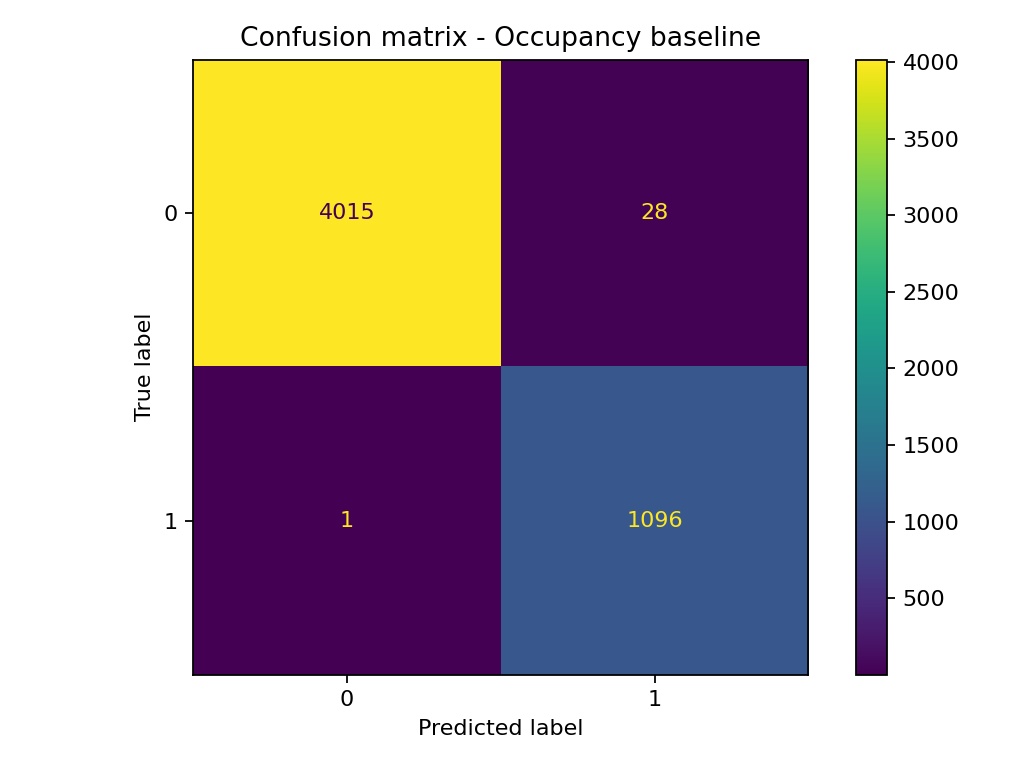

In [9]:
from IPython.display import Image

Image("outputs/figures/02_confusion_matrix.png")